In [1]:
import os
import json
import math
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, classification_report

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

TensorFlow: 2.21.0
NumPy: 1.26.4
Pandas: 3.0.3


In [31]:
# CONFIG

CSV_PATH = "iot_health_monitoring_dataset.csv"

OUTPUT_DIR = "./watch12_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAME = "tiny_uc2_autoencoder"
MODEL_VERSION = "tiny_ae_uc2_watch12_v0.1.0"

TFLITE_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "tiny_uc2_autoencoder.tflite")
SCALER_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "tiny_uc2_scaler.json")
METADATA_OUTPUT_PATH = os.path.join(OUTPUT_DIR, "tiny_uc2_metadata.json")

RANDOM_SEED = 42
VAL_SIZE = 0.2
TEST_SIZE = 0.15

BATCH_SIZE = 64
MAX_EPOCHS = 200
EARLY_STOPPING_PATIENCE = 12

THRESHOLD_PERCENTILE = 97.5

# The new 12D Watch-Native feature contract.
FEATURE_COLS = [
    "heart_rate",
    "blood_oxygen",
    "respiratory_rate",
    "hrv_sdnn",
    "body_temperature",
    "activity_level",
    "steps_count",
    "calories_burned",
    "sleep_quality",
    "hour_sin",
    "hour_cos",
    "is_sleep_window",
]

# Explicitly excluded from the autoencoder tensor.
EXCLUDED_FROM_TENSOR = [
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "glucose_level",
    "stress_level",
    "pulse_pressure",
    "mean_arterial_pressure",
]

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Output directory:", OUTPUT_DIR)
print("Feature count:", len(FEATURE_COLS))
print(FEATURE_COLS)

Output directory: ./watch12_artifacts
Feature count: 12
['heart_rate', 'blood_oxygen', 'respiratory_rate', 'hrv_sdnn', 'body_temperature', 'activity_level', 'steps_count', 'calories_burned', 'sleep_quality', 'hour_sin', 'hour_cos', 'is_sleep_window']


In [5]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

display(df.head())

Shape: (5094, 17)
Columns:
['timestamp', 'device_id', 'patient_id', 'heart_rate', 'blood_oxygen', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level', 'body_temperature', 'respiratory_rate', 'activity_level', 'sleep_quality', 'stress_level', 'hrv_sdnn', 'steps_count', 'calories_burned', 'health_event']


,timestamp,device_id,patient_id,heart_rate,blood_oxygen,blood_pressure_systolic,blood_pressure_diastolic,glucose_level,body_temperature,respiratory_rate,activity_level,sleep_quality,stress_level,hrv_sdnn,steps_count,calories_burned,health_event
0,2025-09-30 13:06:45.056387,DEVICE_0040,PATIENT_0310,88.7,91.9,178.0,100.0,131.1,97.66,23.3,0.486,0.215,0.778,12.7,2189,2033,3
1,2025-09-30 13:30:45.056387,DEVICE_0078,PATIENT_0147,82.3,96.5,122.0,82.0,57.7,98.89,19.9,0.650,0.671,0.296,58.1,11342,2634,0
2,2025-09-30 13:46:45.056387,DEVICE_0013,PATIENT_0129,101.7,91.3,139.0,102.0,143.4,98.89,26.5,0.490,0.395,0.772,17.2,3456,2157,3
3,2025-09-30 13:48:45.056387,DEVICE_0085,PATIENT_0470,73.9,98.3,121.0,88.0,108.5,98.73,16.5,0.445,0.707,0.339,97.2,8300,1631,0
4,2025-09-30 14:15:45.056387,DEVICE_0055,PATIENT_0245,75.7,93.0,109.0,81.0,109.2,98.74,14.2,0.612,0.844,0.197,64.1,7337,2498,0


In [7]:
print("Dataset shape:", df.shape)

if "health_event" in df.columns:
    print("\nhealth_event counts:")
    print(df["health_event"].value_counts(dropna=False))

if "patient_id" in df.columns:
    print("\nUnique patients:", df["patient_id"].nunique())

if "timestamp" in df.columns:
    print("\nTimestamp sample:")
    print(df["timestamp"].head())

Dataset shape: (5094, 17)

health_event counts:
health_event
0    4330
1     306
2     267
3     191
Name: count, dtype: int64

Unique patients: 500

Timestamp sample:
0    2025-09-30 13:06:45.056387
1    2025-09-30 13:30:45.056387
2    2025-09-30 13:46:45.056387
3    2025-09-30 13:48:45.056387
4    2025-09-30 14:15:45.056387
Name: timestamp, dtype: str


In [9]:
# Parse timestamp

if "timestamp" not in df.columns:
    raise ValueError("Dataset must contain a 'timestamp' column.")

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

missing_ts = df["timestamp"].isna().sum()
print("Rows with invalid timestamp:", missing_ts)

df = df.dropna(subset=["timestamp"]).copy()

# Derive watch-native temporal features

hour = df["timestamp"].dt.hour.astype(float)

df["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
df["is_sleep_window"] = ((hour >= 22) | (hour <= 6)).astype(float)

display(df[["timestamp", "hour_sin", "hour_cos", "is_sleep_window"]].head())

Rows with invalid timestamp: 0


,timestamp,hour_sin,hour_cos,is_sleep_window
0,2025-09-30 13:06:45.056387,-0.258819,-0.965926,0.0
1,2025-09-30 13:30:45.056387,-0.258819,-0.965926,0.0
2,2025-09-30 13:46:45.056387,-0.258819,-0.965926,0.0
3,2025-09-30 13:48:45.056387,-0.258819,-0.965926,0.0
4,2025-09-30 14:15:45.056387,-0.500000,-0.866025,0.0


In [11]:
missing_cols = [c for c in FEATURE_COLS if c not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required feature columns: {missing_cols}")

if "health_event" not in df.columns:
    raise ValueError("Dataset must contain 'health_event' label column.")

print("All required 12D feature columns are present.")

All required 12D feature columns are present.


In [13]:
# Convert all feature columns to numeric.
for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Replace inf with NaN.
df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

print("Missing values per feature before drop:")
print(df[FEATURE_COLS].isna().sum())

# For model training, require complete 12D rows.
# Important: do not fill BP/glucose/etc. They are excluded entirely.
df_model = df.dropna(subset=FEATURE_COLS + ["health_event"]).copy()

print("\nOriginal rows:", len(df))
print("Usable complete 12D rows:", len(df_model))

print("\nhealth_event counts after cleaning:")
print(df_model["health_event"].value_counts(dropna=False))

Missing values per feature before drop:
heart_rate          0
blood_oxygen        0
respiratory_rate    0
hrv_sdnn            0
body_temperature    0
activity_level      0
steps_count         0
calories_burned     0
sleep_quality       0
hour_sin            0
hour_cos            0
is_sleep_window     0
dtype: int64

Original rows: 5094
Usable complete 12D rows: 5094

health_event counts after cleaning:
health_event
0    4330
1     306
2     267
3     191
Name: count, dtype: int64


In [15]:
# Broad physiologic validity bounds for training data hygiene.
# These are not the same as runtime emergency rules.
BOUNDS = {
    "heart_rate": (20, 220),
    "blood_oxygen": (70, 100),
    "respiratory_rate": (6, 50),
    "hrv_sdnn": (1, 250),
    "body_temperature": (90, 108),
    "activity_level": (0, 1.5),
    "steps_count": (0, 100000),
    "calories_burned": (0, 10000),
    "sleep_quality": (0, 1),
    "hour_sin": (-1.01, 1.01),
    "hour_cos": (-1.01, 1.01),
    "is_sleep_window": (0, 1),
}

before = len(df_model)

mask = np.ones(len(df_model), dtype=bool)

for col, (lo, hi) in BOUNDS.items():
    mask &= df_model[col].between(lo, hi)

df_model = df_model[mask].copy()

after = len(df_model)

print("Rows before sanity filtering:", before)
print("Rows after sanity filtering:", after)
print("Rows removed:", before - after)

print("\nhealth_event counts after sanity filtering:")
print(df_model["health_event"].value_counts(dropna=False))

Rows before sanity filtering: 5094
Rows after sanity filtering: 5094
Rows removed: 0

health_event counts after sanity filtering:
health_event
0    4330
1     306
2     267
3     191
Name: count, dtype: int64


In [17]:
# Treat health_event == 0 as normal.
# Any non-zero health_event is considered anomaly/event for evaluation only.
df_model["is_normal"] = df_model["health_event"].astype(int) == 0
df_model["is_anomaly_label"] = ~df_model["is_normal"]

normal_df = df_model[df_model["is_normal"]].copy()
anomaly_df = df_model[df_model["is_anomaly_label"]].copy()

print("Normal rows:", len(normal_df))
print("Anomaly/event rows:", len(anomaly_df))

if len(normal_df) < 100:
    raise ValueError("Not enough normal rows to train an autoencoder.")

Normal rows: 4330
Anomaly/event rows: 764


In [21]:
def patient_level_split(df_normal, val_size=0.2, test_size=0.15, seed=42):
    """
    Splits normal data by patient_id if available.
    Otherwise falls back to row-level split.

    This version explicitly converts patient_id values to plain Python strings
    to avoid pandas/pyarrow indexing issues with sklearn.train_test_split().
    """
    
    has_patient_id = (
        "patient_id" in df_normal.columns
        and df_normal["patient_id"].notna().sum() > 0
        and df_normal["patient_id"].nunique() >= 5
    )
    
    if has_patient_id:
      
        patients = (
            df_normal["patient_id"]
            .dropna()
            .astype(str)
            .unique()
            .tolist()
        )
        
        print("Using patient-level split.")
        print("Number of unique normal patients:", len(patients))
        
        train_val_patients, test_patients = train_test_split(
            patients,
            test_size=test_size,
            random_state=seed,
            shuffle=True,
        )
        
        adjusted_val_size = val_size / (1.0 - test_size)
        
        train_patients, val_patients = train_test_split(
            train_val_patients,
            test_size=adjusted_val_size,
            random_state=seed,
            shuffle=True,
        )
        
        pid_series = df_normal["patient_id"].astype(str)
        
        train_df = df_normal[pid_series.isin(train_patients)].copy()
        val_df = df_normal[pid_series.isin(val_patients)].copy()
        test_normal_df = df_normal[pid_series.isin(test_patients)].copy()
        
        split_info = {
            "split_type": "patient_level",
            "train_patients": int(len(train_patients)),
            "val_patients": int(len(val_patients)),
            "test_patients": int(len(test_patients)),
        }
        
    else:
        print("Using row-level split.")
        
        train_val_df, test_normal_df = train_test_split(
            df_normal,
            test_size=test_size,
            random_state=seed,
            shuffle=True,
        )
        
        adjusted_val_size = val_size / (1.0 - test_size)
        
        train_df, val_df = train_test_split(
            train_val_df,
            test_size=adjusted_val_size,
            random_state=seed,
            shuffle=True,
        )
        
        split_info = {
            "split_type": "row_level",
            "train_patients": None,
            "val_patients": None,
            "test_patients": None,
        }
    
    return train_df, val_df, test_normal_df, split_info

train_df, val_df, test_normal_df, split_info = patient_level_split(
    normal_df,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    seed=RANDOM_SEED
)

print("\nSplit info:")
print(split_info)

print("\nRows:")
print("Train normal rows:", len(train_df))
print("Val normal rows:", len(val_df))
print("Test normal rows:", len(test_normal_df))
print("Anomaly/event rows available for evaluation:", len(anomaly_df))

# Safety checks
assert len(train_df) > 0, "Train split is empty."
assert len(val_df) > 0, "Validation split is empty."
assert len(test_normal_df) > 0, "Test-normal split is empty."

if split_info["split_type"] == "patient_level":
    train_pids = set(train_df["patient_id"].astype(str).unique())
    val_pids = set(val_df["patient_id"].astype(str).unique())
    test_pids = set(test_normal_df["patient_id"].astype(str).unique())
    
    assert train_pids.isdisjoint(val_pids), "Patient leakage: train/val overlap."
    assert train_pids.isdisjoint(test_pids), "Patient leakage: train/test overlap."
    assert val_pids.isdisjoint(test_pids), "Patient leakage: val/test overlap."
    
    print("\nPatient-level leakage checks passed.")

Using patient-level split.
Number of unique normal patients: 500

Split info:
{'split_type': 'patient_level', 'train_patients': 324, 'val_patients': 101, 'test_patients': 75}

Rows:
Train normal rows: 2820
Val normal rows: 878
Test normal rows: 632
Anomaly/event rows available for evaluation: 764

Patient-level leakage checks passed.


In [25]:
scaler = StandardScaler()

X_train_raw = train_df[FEATURE_COLS].values.astype("float32")
X_val_raw = val_df[FEATURE_COLS].values.astype("float32")
X_test_normal_raw = test_normal_df[FEATURE_COLS].values.astype("float32")

X_train = scaler.fit_transform(X_train_raw).astype("float32")
X_val = scaler.transform(X_val_raw).astype("float32")
X_test_normal = scaler.transform(X_test_normal_raw).astype("float32")

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test_normal:", X_test_normal.shape)

print("\nScaler mean length:", len(scaler.mean_))
print("Scaler scale length:", len(scaler.scale_))
print("\nMeans:")
print(scaler.mean_)
print("\nScales:")
print(scaler.scale_)

X_train: (2820, 12)
X_val: (878, 12)
X_test_normal: (632, 12)

Scaler mean length: 12
Scaler scale length: 12

Means:
[ 7.52294681e+01  9.69929433e+01  1.60414893e+01  5.01842553e+01
  9.86010212e+01  5.49581206e-01  7.48816986e+03  2.15488582e+03
  7.74232979e-01 -6.34997802e-03  6.76474271e-03  3.76595745e-01]

Scales:
[9.81635526e+00 1.43983963e+00 1.98577615e+00 1.52801159e+01
 4.90030269e-01 1.44904168e-01 2.59125163e+03 3.79810131e+02
 1.01361980e-01 7.12138867e-01 7.01977298e-01 4.84532135e-01]


In [27]:
def build_autoencoder(input_dim=12):
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(input_dim,), name="features"),
            tf.keras.layers.Dense(8, activation="relu", name="encoder_dense_8"),
            tf.keras.layers.Dense(4, activation="relu", name="latent_dense_4"),
            tf.keras.layers.Dense(8, activation="relu", name="decoder_dense_8"),
            tf.keras.layers.Dense(input_dim, activation="linear", name="reconstruction"),
        ],
        name=MODEL_NAME
    )
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse"
    )
    
    return model

model = build_autoencoder(input_dim=len(FEATURE_COLS))
model.summary()

Model: "tiny_uc2_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder_dense_8 (Dense)              │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ latent_dense_4 (Dense)               │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder_dense_8 (Dense)              │ (None, 8)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reconstruction (Dense)               │ (None, 12)                  │             108 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 288 (1.12 KB)

 Trainable params: 288 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1,
    )
]

history = model.fit(
    X_train,
    X_train,
    validation_data=(X_val, X_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

epochs_ran = len(history.history["loss"])
print("Epochs ran:", epochs_ran)

Epoch 1/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5217 - val_loss: 0.5264 - learning_rate: 0.0010
Epoch 2/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5213 - val_loss: 0.5261 - learning_rate: 0.0010
Epoch 3/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5210 - val_loss: 0.5259 - learning_rate: 0.0010
Epoch 4/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5208 - val_loss: 0.5256 - learning_rate: 0.0010
Epoch 5/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5205 - val_loss: 0.5254 - learning_rate: 0.0010
Epoch 6/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5202 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 7/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5200 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 8/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5197 - val_loss: 0.5248 - learning_rate: 0.0010
Epoch 9/200
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5195 - val_loss: 0.5246 - learning_rate: 0.0010
Epoch 10/200
45/45 

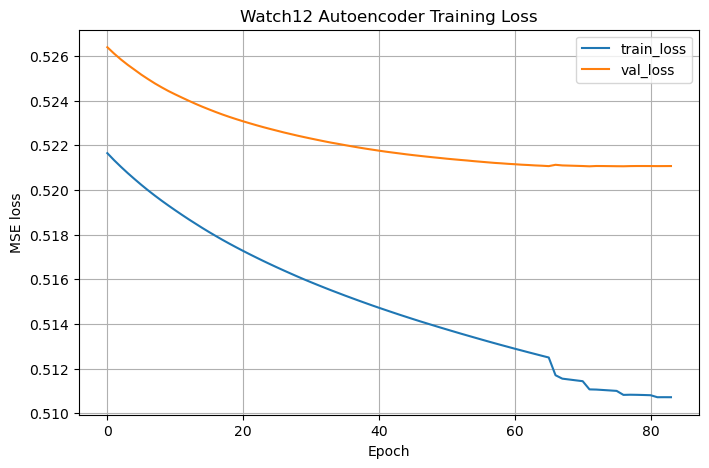

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Watch12 Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
def reconstruction_mse(x_scaled, reconstructed_scaled):
    return np.mean(np.square(x_scaled - reconstructed_scaled), axis=1)

X_val_pred = model.predict(X_val, verbose=0)
val_mse = reconstruction_mse(X_val, X_val_pred)

threshold = float(np.percentile(val_mse, THRESHOLD_PERCENTILE))

print("Validation normal MSE summary:")
print(pd.Series(val_mse).describe(percentiles=[0.5, 0.9, 0.95, 0.975, 0.99]))

print(f"\nSelected threshold p{THRESHOLD_PERCENTILE}: {threshold:.8f}")

Validation normal MSE summary:
count    878.000000
mean       0.521062
std        0.261506
min        0.061760
50%        0.490052
90%        0.872613
95%        1.023319
97.5%      1.144716
99%        1.253202
max        1.566784
dtype: float64

Selected threshold p97.5: 1.14471610


In [39]:
X_test_normal_pred = model.predict(X_test_normal, verbose=0)
test_normal_mse = reconstruction_mse(X_test_normal, X_test_normal_pred)

normal_false_positive_rate = float(np.mean(test_normal_mse > threshold))

print("Held-out normal MSE summary:")
print(pd.Series(test_normal_mse).describe(percentiles=[0.5, 0.9, 0.95, 0.975, 0.99]))

print("\nNormal false positive rate at threshold:", normal_false_positive_rate)

# Evaluate anomaly/event rows if available.
if len(anomaly_df) > 0:
    X_anom_raw = anomaly_df[FEATURE_COLS].values.astype("float32")
    X_anom = scaler.transform(X_anom_raw).astype("float32")
    X_anom_pred = model.predict(X_anom, verbose=0)
    anom_mse = reconstruction_mse(X_anom, X_anom_pred)
    
    anomaly_detection_rate = float(np.mean(anom_mse > threshold))
    
    print("\nAnomaly/event MSE summary:")
    print(pd.Series(anom_mse).describe(percentiles=[0.5, 0.9, 0.95, 0.975, 0.99]))
    
    print("\nAnomaly/event detection rate at threshold:", anomaly_detection_rate)
    
    # Combined label metrics
    y_true = np.concatenate([
        np.zeros(len(test_normal_mse), dtype=int),
        np.ones(len(anom_mse), dtype=int),
    ])
    
    y_score = np.concatenate([
        test_normal_mse,
        anom_mse,
    ])
    
    y_pred = (y_score > threshold).astype(int)
    
    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception:
        auc = None
    
    print("\nROC AUC:", auc)
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["normal", "event/anomaly"]))
else:
    anom_mse = np.array([])
    anomaly_detection_rate = None
    auc = None

Held-out normal MSE summary:
count    632.000000
mean       0.511615
std        0.256688
min        0.059482
50%        0.471837
90%        0.856211
95%        1.015212
97.5%      1.166972
99%        1.301209
max        1.641661
dtype: float64

Normal false positive rate at threshold: 0.028481012658227847

Anomaly/event MSE summary:
count    764.000000
mean       2.146761
std        1.111503
min        0.292924
50%        1.888736
90%        3.523760
95%        4.343988
97.5%      5.144958
99%        6.061962
max        7.596615
dtype: float64

Anomaly/event detection rate at threshold: 0.8678010471204188

ROC AUC: 0.9784342070382397

Classification report:
               precision    recall  f1-score   support

       normal       0.86      0.97      0.91       632
event/anomaly       0.97      0.87      0.92       764

     accuracy                           0.91      1396
    macro avg       0.92      0.92      0.91      1396
 weighted avg       0.92      0.91      0.91      1396



In [42]:
def top_contributors_for_row(x_scaled, x_recon, original_row, feature_cols, k=5):
    errors = np.square(x_scaled - x_recon)
    idx = np.argsort(errors)[::-1][:k]
    
    return [
        {
            "feature": feature_cols[i],
            "contribution": float(errors[i]),
            "original_value": float(original_row[feature_cols[i]])
        }
        for i in idx
    ]

# Show top contributors for a few high-error validation normals.
high_idx = np.argsort(val_mse)[::-1][:5]

for rank, i in enumerate(high_idx, start=1):
    original_row = val_df.iloc[i]
    contributors = top_contributors_for_row(
        X_val[i],
        X_val_pred[i],
        original_row,
        FEATURE_COLS,
        k=5
    )
    
    print(f"\nValidation high-error normal #{rank}")
    print("MSE:", val_mse[i])
    print(contributors)


Validation high-error normal #1
MSE: 1.5667839
[{'feature': 'body_temperature', 'contribution': 4.493640422821045, 'original_value': 97.54}, {'feature': 'hrv_sdnn', 'contribution': 3.850604772567749, 'original_value': 69.9}, {'feature': 'blood_oxygen', 'contribution': 3.22133207321167, 'original_value': 94.4}, {'feature': 'respiratory_rate', 'contribution': 2.4445011615753174, 'original_value': 18.6}, {'feature': 'hour_sin', 'contribution': 1.2862887382507324, 'original_value': -0.5000000000000004}]

Validation high-error normal #2
MSE: 1.5338626
[{'feature': 'body_temperature', 'contribution': 7.949329853057861, 'original_value': 100.05}, {'feature': 'calories_burned', 'contribution': 2.77579402923584, 'original_value': 2703.0}, {'feature': 'blood_oxygen', 'contribution': 2.727278470993042, 'original_value': 99.2}, {'feature': 'steps_count', 'contribution': 1.7757058143615723, 'original_value': 4216.0}, {'feature': 'hour_cos', 'contribution': 1.0329433679580688, 'original_value': 6.1

In [44]:
scaler_payload = {
    "feature_cols": FEATURE_COLS,
    "mean": [float(x) for x in scaler.mean_],
    "scale": [float(x) for x in scaler.scale_],
}

with open(SCALER_OUTPUT_PATH, "w") as f:
    json.dump(scaler_payload, f, indent=2)

print("Wrote scaler:", SCALER_OUTPUT_PATH)

with open(SCALER_OUTPUT_PATH, "r") as f:
    print(f.read())

Wrote scaler: ./watch12_artifacts\tiny_uc2_scaler.json
{
  "feature_cols": [
    "heart_rate",
    "blood_oxygen",
    "respiratory_rate",
    "hrv_sdnn",
    "body_temperature",
    "activity_level",
    "steps_count",
    "calories_burned",
    "sleep_quality",
    "hour_sin",
    "hour_cos",
    "is_sleep_window"
  ],
  "mean": [
    75.22946807644891,
    96.99294329163031,
    16.04148934648392,
    50.18425528191506,
    98.60102122421806,
    0.5495812062147661,
    7488.169858156029,
    2154.885815602837,
    0.7742329788968918,
    -0.006349978020005192,
    0.006764742710911636,
    0.37659574468085105
  ],
  "scale": [
    9.81635525790522,
    1.4398396289392716,
    1.9857761516029817,
    15.280115927762221,
    0.4900302690857054,
    0.14490416797002703,
    2591.2516294184575,
    379.8101313789479,
    0.10136198037721751,
    0.7121388667366454,
    0.7019772981352157,
    0.4845321349189611
  ]
}


In [46]:
metadata = {
    "model_name": MODEL_NAME,
    "model_version": MODEL_VERSION,
    "model_type": "dense_autoencoder",
    "input_dim": len(FEATURE_COLS),
    "feature_cols": FEATURE_COLS,
    "threshold": threshold,
    "threshold_percentile": THRESHOLD_PERCENTILE,
    "threshold_source": "validation_normal_reconstruction_error",
    "health_event_mapping": {
        "0": "normal",
        "1": "event/anomaly",
        "2": "event/anomaly",
        "3": "event/anomaly",
    },
    "training": {
        "normal_train_rows": int(len(train_df)),
        "normal_val_rows": int(len(val_df)),
        "normal_test_rows": int(len(test_normal_df)),
        "event_eval_rows": int(len(anomaly_df)),
        "epochs_ran": int(epochs_ran),
        "batch_size": int(BATCH_SIZE),
        "random_seed": int(RANDOM_SEED),
        **split_info,
    },
    "evaluation": {
        "validation_normal_mse_mean": float(np.mean(val_mse)),
        "validation_normal_mse_std": float(np.std(val_mse)),
        "validation_normal_mse_p95": float(np.percentile(val_mse, 95)),
        "validation_normal_mse_p975": float(np.percentile(val_mse, 97.5)),
        "validation_normal_mse_p99": float(np.percentile(val_mse, 99)),
        "test_normal_false_positive_rate": normal_false_positive_rate,
        "event_detection_rate": anomaly_detection_rate,
        "roc_auc_if_events_available": None if auc is None else float(auc),
    },
    "preprocessing": {
        "scaler": "StandardScaler",
        "scaler_fit_scope": "normal_train_rows_only",
        "timestamp_required": True,
        "derived_features": [
            "hour_sin",
            "hour_cos",
            "is_sleep_window",
        ],
        "excluded_from_tensor": EXCLUDED_FROM_TENSOR,
        "missing_policy": "training_rows_with_missing_watch12_features_dropped",
        "patient_level_split": split_info["split_type"] == "patient_level",
    },
    "runtime_note": [
        "Runtime must construct exactly a 12-element float32 vector in feature_cols order.",
        "Runtime must scale the vector using tiny_uc2_scaler.json before TFLite inference.",
        "The TFLite model reconstructs the scaled 12D input vector.",
        "AE score is mean squared reconstruction error across the 12 scaled features.",
    ],
    "clinical_safety_note": [
        "Blood pressure, glucose, pulse pressure, mean arterial pressure, and non-watch clinical values are excluded from the AE tensor.",
        "External BP cuff, CGM, EHR baselines, and care-plan thresholds must be evaluated in the TypeScript decision/rule layer.",
        "The autoencoder is not a diagnostic model and must not override emergency rules or caregiver HITL safety floors.",
    ],
}

with open(METADATA_OUTPUT_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print("Wrote metadata:", METADATA_OUTPUT_PATH)

with open(METADATA_OUTPUT_PATH, "r") as f:
    print(f.read())

Wrote metadata: ./watch12_artifacts\tiny_uc2_metadata.json
{
  "model_name": "tiny_uc2_autoencoder",
  "model_version": "tiny_ae_uc2_watch12_v0.1.0",
  "model_type": "dense_autoencoder",
  "input_dim": 12,
  "feature_cols": [
    "heart_rate",
    "blood_oxygen",
    "respiratory_rate",
    "hrv_sdnn",
    "body_temperature",
    "activity_level",
    "steps_count",
    "calories_burned",
    "sleep_quality",
    "hour_sin",
    "hour_cos",
    "is_sleep_window"
  ],
  "threshold": 1.1447160959243772,
  "threshold_percentile": 97.5,
  "threshold_source": "validation_normal_reconstruction_error",
  "health_event_mapping": {
    "0": "normal",
    "1": "event/anomaly",
    "2": "event/anomaly",
    "3": "event/anomaly"
  },
  "training": {
    "normal_train_rows": 2820,
    "normal_val_rows": 878,
    "normal_test_rows": 632,
    "event_eval_rows": 764,
    "epochs_ran": 84,
    "batch_size": 64,
    "random_seed": 42,
    "split_type": "patient_level",
    "train_patients": 324,
    "va

In [48]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Float32 model, no quantization.
tflite_model = converter.convert()

with open(TFLITE_OUTPUT_PATH, "wb") as f:
    f.write(tflite_model)

print("Wrote TFLite model:", TFLITE_OUTPUT_PATH)
print("TFLite size bytes:", os.path.getsize(TFLITE_OUTPUT_PATH))

INFO:tensorflow:Assets written to: C:\Users\jaymo\AppData\Local\Temp\tmp28pe2q9c\assets


INFO:tensorflow:Assets written to: C:\Users\jaymo\AppData\Local\Temp\tmp28pe2q9c\assets


Saved artifact at 'C:\Users\jaymo\AppData\Local\Temp\tmp28pe2q9c'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 12), dtype=tf.float32, name=None)
Captures:
  3046158121680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3046158966544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3046158965968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3046158964816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3046158966352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3046158964624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3046158967504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3046158965776: TensorSpec(shape=(), dtype=tf.resource, name=None)
Wrote TFLite model: ./watch12_artifacts\tiny_uc2_autoencoder.tflite
TFLite size bytes: 3908


In [50]:
interpreter = tf.lite.Interpreter(model_path=TFLITE_OUTPUT_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:")
for d in input_details:
    print(d)

print("\nOutput details:")
for d in output_details:
    print(d)

input_shape = input_details[0]["shape"].tolist()
output_shape = output_details[0]["shape"].tolist()

assert input_shape == [1, 12], f"Expected input shape [1, 12], got {input_shape}"
assert output_shape == [1, 12], f"Expected output shape [1, 12], got {output_shape}"

print("\nTFLite shape verification passed.")

Input details:
{'name': 'serving_default_features:0', 'index': 0, 'shape': array([ 1, 12]), 'shape_signature': array([-1, 12]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}

Output details:
{'name': 'StatefulPartitionedCall_1:0', 'index': 12, 'shape': array([ 1, 12]), 'shape_signature': array([-1, 12]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}

TFLite shape verification passed.


C:\Users\jaymo\anaconda3\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [52]:
sample = X_val[:1].astype("float32")

keras_out = model.predict(sample, verbose=0)

interpreter.set_tensor(input_details[0]["index"], sample)
interpreter.invoke()
tflite_out = interpreter.get_tensor(output_details[0]["index"])

print("Sample input shape:", sample.shape)
print("Keras output shape:", keras_out.shape)
print("TFLite output shape:", tflite_out.shape)

max_abs_diff = np.max(np.abs(keras_out - tflite_out))
print("Max abs diff Keras vs TFLite:", max_abs_diff)

sample_mse_keras = np.mean(np.square(sample - keras_out), axis=1)[0]
sample_mse_tflite = np.mean(np.square(sample - tflite_out), axis=1)[0]

print("Sample MSE Keras:", sample_mse_keras)
print("Sample MSE TFLite:", sample_mse_tflite)

Sample input shape: (1, 12)
Keras output shape: (1, 12)
TFLite output shape: (1, 12)
Max abs diff Keras vs TFLite: 7.748604e-07
Sample MSE Keras: 0.3530501
Sample MSE TFLite: 0.35305014
